## Exploratory Data Analysis ##

In [1]:
%pip install --upgrade pandas
%pip install pathlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [3]:
#Setting the path
data_path = Path('/Users/Priyanka/Documents/Internship-Internmo/Zomato_BI_Project/data/cleaned')

In [4]:
#loading the cleaned datasets
cities = pd.read_csv(data_path / 'cities_cleaned.csv')
customer_feedback = pd.read_csv(data_path / 'customer_feedback_cleaned.csv')
customers = pd.read_csv(data_path / 'customers_cleaned.csv')
delivery_partners = pd.read_csv(data_path / 'delivery_partners_cleaned.csv')
menu = pd.read_csv(data_path / 'menu_cleaned.csv')
order_items = pd.read_csv(data_path / 'order_items_cleaned.csv')
orders = pd.read_csv(data_path / 'orders_cleaned.csv')
payments = pd.read_csv(data_path / 'payments_cleaned.csv')
promotions = pd.read_csv(data_path / 'promotions_cleaned.csv')
restaurants = pd.read_csv(data_path / 'restaurants_cleaned.csv')
traffic = pd.read_csv(data_path / 'traffic_cleaned.csv')
weather = pd.read_csv(data_path / 'weather_cleaned.csv')


In [5]:
#Setting the style for seaborn plots
sns.set_theme(style="darkgrid", palette="pastel")
plt.rcParams["font.sans-serif"] = "Helvetica"
plt.rcParams["axes.edgecolor"] = "#CCCCCC"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["figure.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

In [6]:
# Palette Definition
ZOMATO_RED = "#E23744"
ZOMATO_DARK_RED = "#CB202D"
CHARCOAL = "#2D2D2D"
NEUTRAL_BOX = "#F4F4F2"
NEUTRAL_GREY = "#E0E0E0"

In [9]:
customers_df = pd.read_csv("/Users/Priyanka/Documents/Internship-Internmo/Zomato_BI_Project/data/cleaned/customers_cleaned.csv")

In [11]:
customers_df.head(5)

,CustomerID,Name,Age,Gender,Phone,Email,City,State,Pincode,RegistrationDate,Membership,TotalOrders,PreferredCuisine
0,1,Aryan Maharaj,35.0,Male,1.960013e+09,Issaconi@Example.Org,Nagpur,Haryana,769177.0,2022-06-11,Basic,4,Fast Food
1,2,Arunima Ahuja,29.0,Male,2.351162e+09,Caleb78@Example.Org,Hyderabad,Tripura,776564.0,2024-02-18,Zomato Pro,6,Mughlai
2,3,Farhan Memon,26.0,Other,3.413165e+08,Kamalapant@Example.Org,Vadodara,Uttarakhand,507888.0,2023-05-17,Gold,5,Mughlai
3,4,Ekbal Garg,26.0,Female,4.835031e+09,Kakardivya@Example.Org,Jaipur,Nagaland,439964.0,2022-05-16,Gold,6,Street Food
4,5,Meghana Shanker,32.0,Female,8.496965e+09,Wchand@Example.Org,Vadodara,Chhattisgarh,489581.0,2024-05-27,Basic,6,Desserts


In [12]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        12000 non-null  int64  
 1   Name              12000 non-null  str    
 2   Age               11574 non-null  float64
 3   Gender            11880 non-null  str    
 4   Phone             11408 non-null  float64
 5   Email             11672 non-null  str    
 6   City              12000 non-null  str    
 7   State             11820 non-null  str    
 8   Pincode           11724 non-null  float64
 9   RegistrationDate  12000 non-null  str    
 10  Membership        11880 non-null  str    
 11  TotalOrders       12000 non-null  int64  
 12  PreferredCuisine  11760 non-null  str    
dtypes: float64(3), int64(2), str(8)
memory usage: 1.2 MB


## 1. Customer Profile & Retention ##

/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_22380/1338104053.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


NameError: name 'cust_merged' is not defined

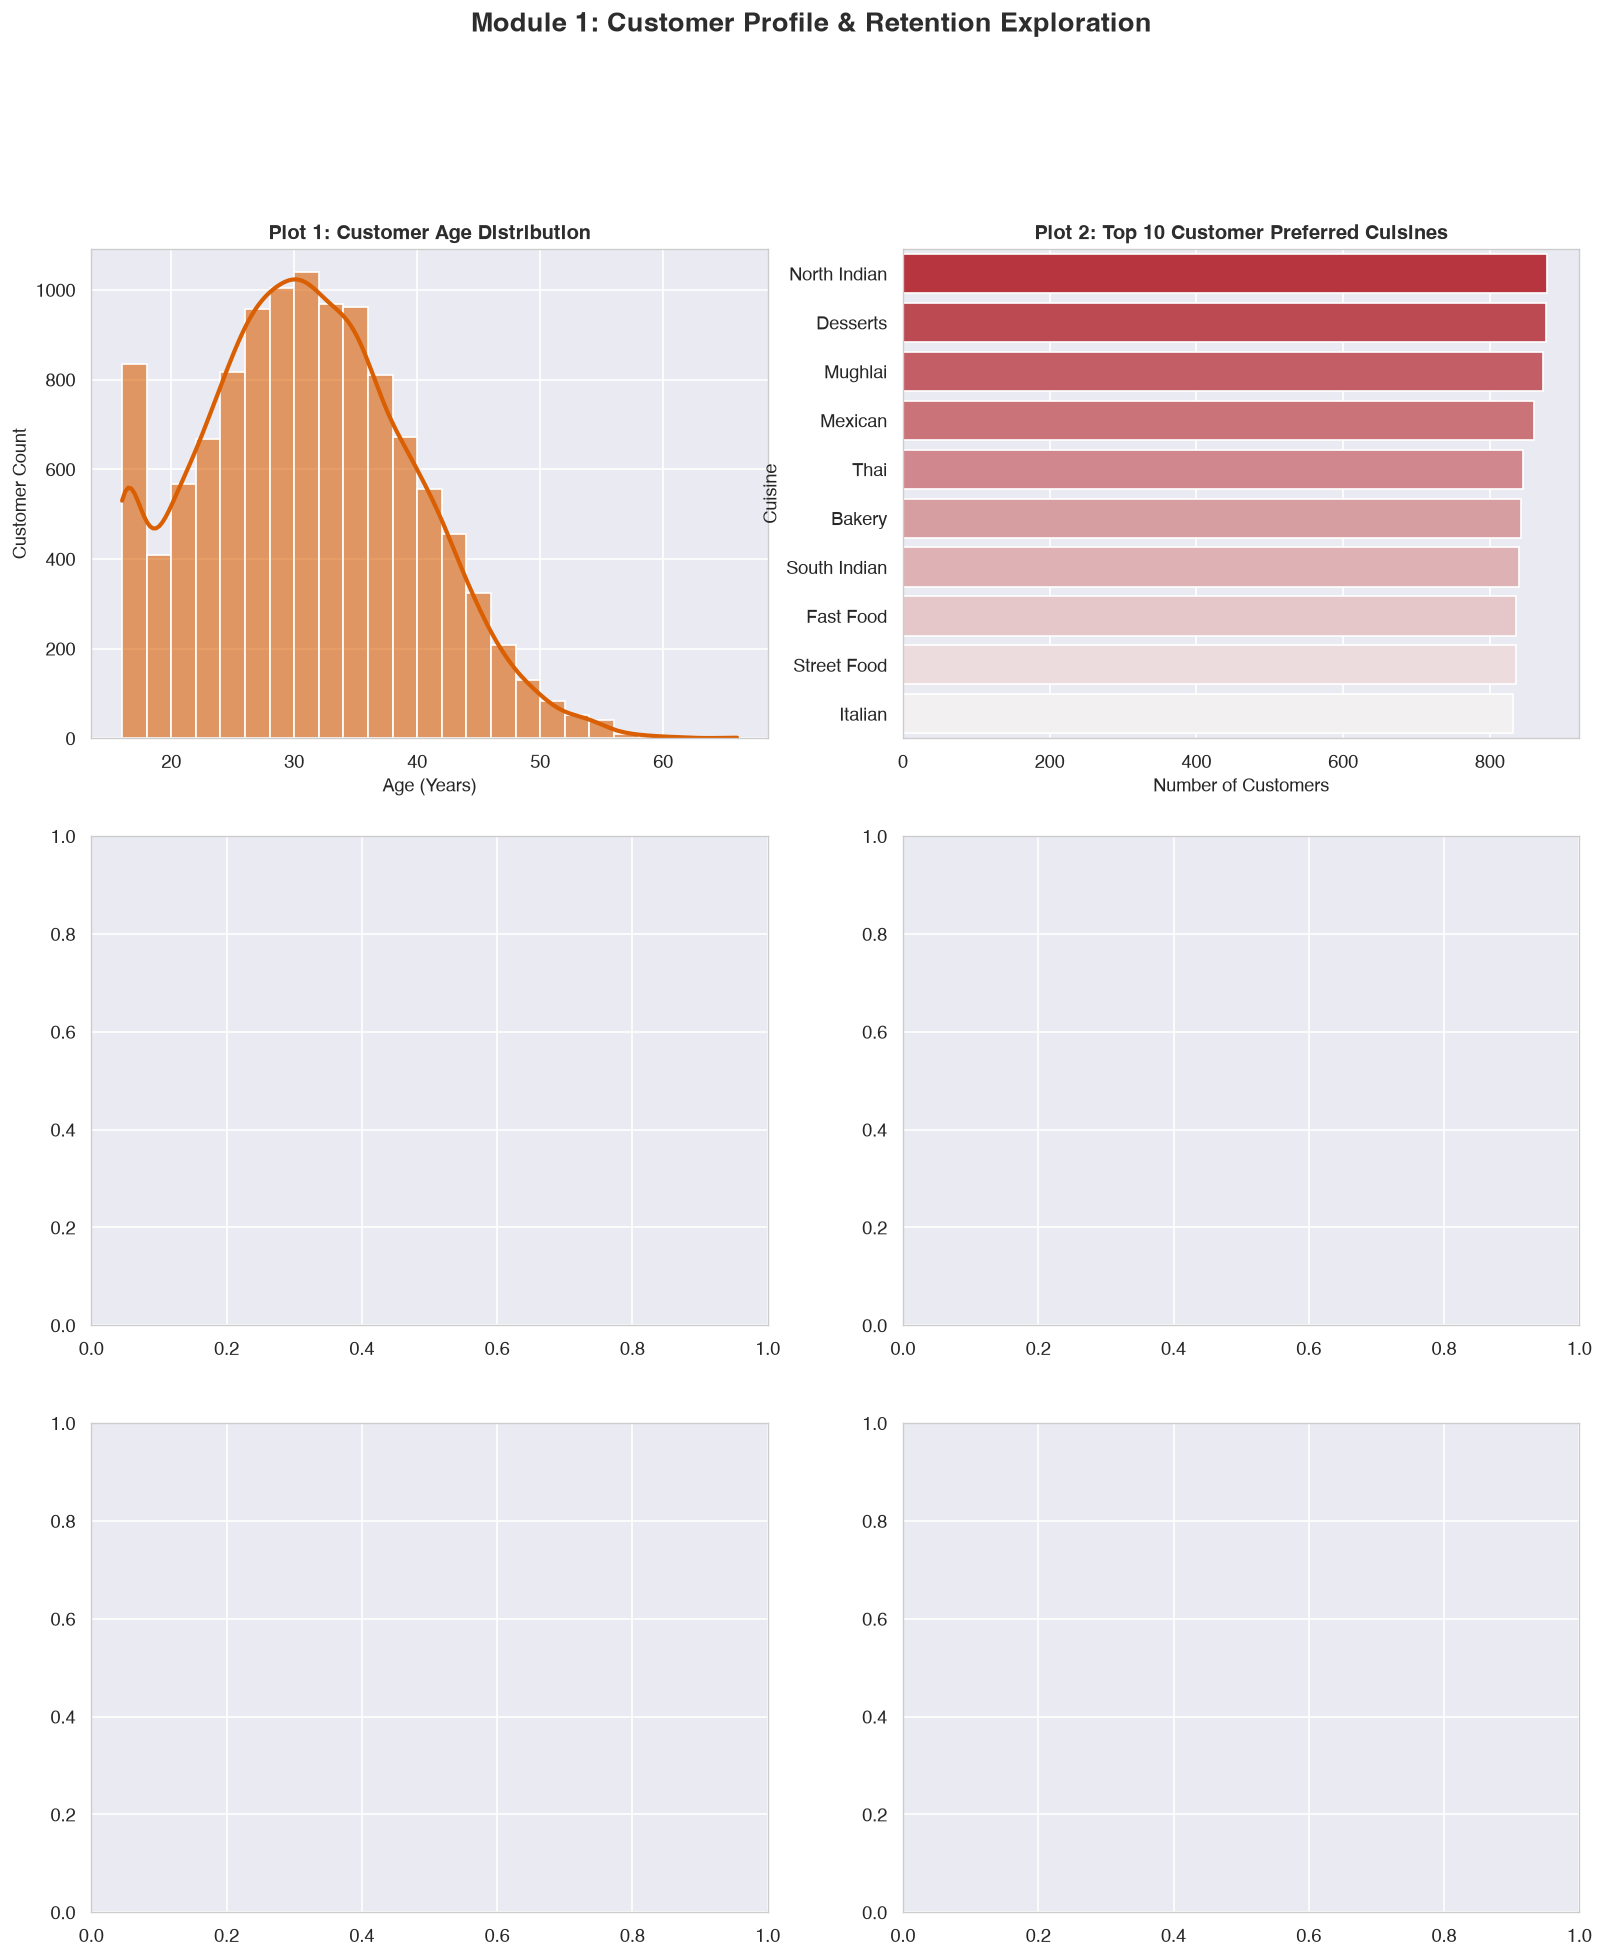

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle(
    "Module 1: Customer Profile & Retention Exploration",
    fontsize=16,
    fontweight="bold",
    color=CHARCOAL,
    y=0.99,
)

#Plot 1: Distribution of Customer Age
sns.histplot(
    data=customers,
    x="Age",
    kde=True,
    bins=25,
    color="#D95F02",  # Terracotta accent
    alpha=0.6,
    edgecolor="white",
    line_kws={"color": CHARCOAL, "linewidth": 2.5},
    ax=axes[0, 0],
)
axes[0, 0].set_title(
    "Plot 1: Customer Age Distribution", fontweight="bold", color=CHARCOAL
)
axes[0, 0].set_xlabel("Age (Years)")
axes[0, 0].set_ylabel("Customer Count")


#Plot 2: Top preferred cuisines
if "PreferredCuisine" in customers.columns:
  top_cuisines = (
      customers["PreferredCuisine"].value_counts().head(10).reset_index()
  )
  top_cuisines.columns = ["Cuisine", "Count"]

  # Generate rank-based gradient palette from Zomato Dark Red down to Light Grey
  rank_palette = sns.light_palette(
      ZOMATO_DARK_RED, n_colors=10, reverse=True
  )

  sns.barplot(
      data=top_cuisines,
      x="Count",
      y="Cuisine",
      palette=rank_palette,
      ax=axes[0, 1],
  )
  axes[0, 1].set_title(
      "Plot 2: Top 10 Customer Preferred Cuisines",
      fontweight="bold",
      color=CHARCOAL,
  )
  axes[0, 1].set_xlabel("Number of Customers")
  axes[0, 1].set_ylabel("Cuisine")

#Plot 3: Orders Per Customer Distribution by City
if "City" in cust_merged.columns:
    top_cities = cust_merged["City"].value_counts().head(6).index
    city_cust = cust_merged[cust_merged["City"].isin(top_cities)]

    sns.boxplot(
        data=city_cust,
        x="City",
        y="TotalOrders",
        color=NEUTRAL_BOX,
        medianprops={"color": ZOMATO_RED, "linewidth": 2.5},
        flierprops={
            "marker": "o",
            "markerfacecolor": CHARCOAL,
            "markeredgecolor": "none",
            "markersize": 4,
            "alpha": 0.5,
        },
        boxprops={"edgecolor": NEUTRAL_GREY},
        ax=axes[1, 0],
    )
    axes[1, 0].set_title("Plot 3: Order Volume per Customer across Top Cities", fontweight="bold", color=CHARCOAL)
    axes[1, 0].set_xlabel("City")
    axes[1, 0].set_ylabel("Orders per Customer")